# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de création et d’entraînement du modèle par *transfer learning*

## Imports et constantes

In [1]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 64

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_from_scratch import (
    build_model_from_pretrained,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
    plot_confusion_matrix,
)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import keras
from keras import layers
from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet_v2 import EfficientNetV2B0
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image_dataset_from_directory
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from collections import Counter
from lxml import etree
from pathlib import Path
from PIL import Image
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cv2
import datetime as dt
import joblib
import itertools as it
import matplotlib.pyplot as plt
import numpy as np
import pytz
import seaborn as sns
sns.set()

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)
# log_file_handler = logging.FileHandler(f"log/{dt.datetime.isoformat(dt.datetime.now(pytz.timezone('Europe/Paris'))).split('.')[0]}.log")
# log_file_handler.setLevel(logging.DEBUG)
# log_cons_handler = logging.StreamHandler()
# log_cons_handler.setLevel(logging.DEBUG)
# log_file_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# log_cons_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# logr.addHandler(log_file_handler)
# logr.addHandler(log_cons_handler)


## Étapes préliminaires : installer les pilotes GPU et tester l'installation

1. Installer ou mettre à jour le pilote pour la GPU. Par ici pour les GPU Nvidia : https://www.nvidia.com/en-us/drivers/ (spécifier le bon modèle dans le formulaire)

2. Installer le dernier CUDA toolkit (v13.2) de chez Nvidia : 

   - soit de la façon [`runfile (local)`][2] :

     ```bash
     # télécharger l'archive (taille approximative : 4,1 Go)
     wget https://developer.download.nvidia.com/compute/cuda/13.2.0/local_installers/cuda_13.2.0_595.45.04_linux.run

     # exécuter l'archive
     sudo sh cuda_13.2.0_595.45.04_linux.run
     ```

   - soit de la façon [`deb (network)`][3] :

     ```bash
     wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/cuda-keyring_1.1-1_all.deb
     
     sudo dpkg -i cuda-keyring_1.1-1_all.deb
     
     sudo apt update
     
     sudo apt -y install cuda-toolkit-13-2
     ```

3. Ajouter les chemins suivants aux variables d'environnement PATH et LD_LIBRARY_PATH :

     ```bash
     echo 'export PATH=/usr/local/cuda/bin:$PATH' >> ~/.bashrc
     echo 'export LD_LIBRARY_PATH=/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH' >> ~/.bashrc

     # Enfin, recharger .bashrc
     source ~/.bashrc
     ```

4. Installer le backend pour Keras (PyTorch, TensorFlow ou JAX) :

   - Pour PyTorch : Suivre [les instructions de la doc PyTorch][1] : Installer le backend `torch` and `torchvision` compatibles CUDA `>=13.0` pour les GPU Nvidia (ou ROCm `>=7.2` pour les GPU AMD).

   - Si besoin, spécifier dans `pyproject.toml` des bornes plus strictes à la version de Python : par exemple, non pas `>=3.12` mais `>=3.12,<3.14`.

5. Installer Keras : Suivre [les instructions de la doc Keras][4]

[1]: https://pytorch.org/get-started/locally/
[2]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=runfile_local
[3]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_network
[4]: https://keras.io/getting_started/

### Tester l'installation de CUDA toolkit et de PyTorch

In [2]:
logr.debug(f"PyTorch version: {torch.__version__}")
logr.debug(f"Is CUDA available: {torch.cuda.is_available()}")
logr.debug(f"CUDA device count: {torch.cuda.device_count()}")
logr.debug(f"Current device: {torch.cuda.current_device()}")
logr.debug(f"Device name: {torch.cuda.get_device_name(0)}")

2026-05-07 12:23:41,571 [DEBUG] PyTorch version: 2.11.0+cu130
2026-05-07 12:23:41,615 [DEBUG] Is CUDA available: True
2026-05-07 12:23:41,634 [DEBUG] CUDA device count: 1
2026-05-07 12:23:41,635 [DEBUG] Current device: 0
2026-05-07 12:23:41,636 [DEBUG] Device name: NVIDIA GeForce RTX 2070 with Max-Q Design


## Entraînement du modèle de prédiction par *transfer learning*

### 1. Modèle à 3 classes et ses différentes variantes

#### 1.0. Split train - val - test (à lancer avant chaque entraînement)

In [2]:
input_img_paths = tuple([
    Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')
])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels_encoded = LabelEncoder().fit_transform(breed_labels)
breed_labels_dict = dict(sorted(zip(breed_labels_encoded, breed_labels)))
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-05-08 00:13:03,949 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))


2026-05-08 00:13:03,966 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-05-08 00:13:03,969 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-05-08 00:13:03,976 [INFO] Train size (0.8): 511
2026-05-08 00:13:03,976 [INFO] Val size (0.1): 64
2026-05-08 00:13:03,977 [INFO] Test size (0.1): 64


In [3]:
train_seq = MyKerasSequence(input_paths_train, labels_train, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)
val_seq = MyKerasSequence(input_paths_val, labels_val, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)
test_seq = MyKerasSequence(input_paths_test, labels_test, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)

#### 1.a) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetB0`

In [4]:
PRTR_MDL = EfficientNetB0
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN_from_{PRTR_MDL.__name__}_{N_CLASSES}_cls_{N_EPOCHS}_eps_{DROPOUT_RATE:.2f}_drpt_{LR}_LR'

Construire le modèle :

In [ ]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_from_EfficientNetB0_3_cls_20_eps_0.20_drpt_1e-05_LR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,058,534 (15.48 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

None

Entraînement et validation :

In [6]:
torch.cuda.empty_cache()

2026-05-07 23:52:39,035 [INFO] Désérialiser l'objet sauvegardé 'models/from_pretrained/CNN_from_EfficientNetB0_3_cls_20_eps_0.20_drpt_1e-05_LR_model.keras'
2026-05-07 23:52:39,868 [INFO] Désérialiser l'objet sauvegardé 'models/from_pretrained/CNN_from_EfficientNetB0_3_cls_20_eps_0.20_drpt_1e-05_LR_history.joblib'


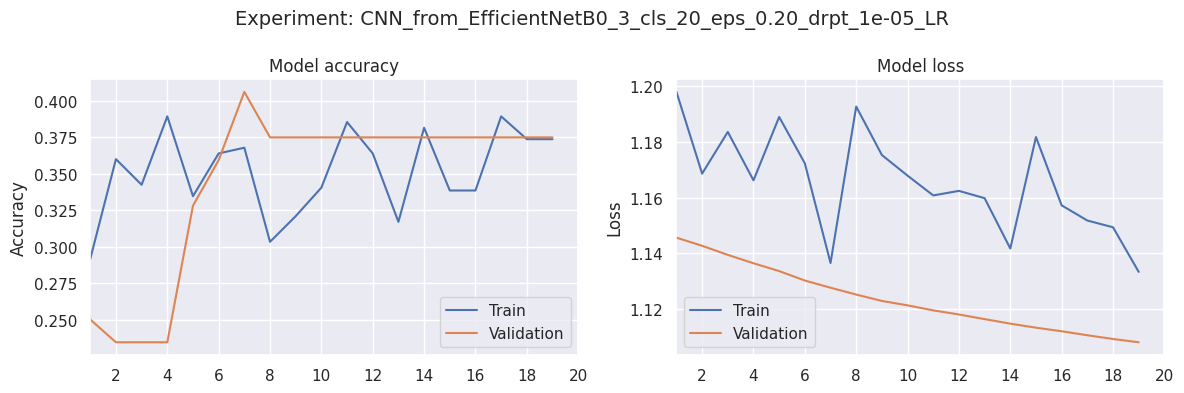

2026-05-07 23:52:41,116 [INFO] Précision finale de l'entraînement: 0.3738
2026-05-07 23:52:41,117 [INFO] Précision finale de la validation: 0.3750
2026-05-07 23:52:41,117 [INFO] Loss finale de l'entraînement: 1.1334
2026-05-07 23:52:41,118 [INFO] Loss finale de la validation: 1.1082


In [7]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'lower right', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-07 23:52:41,126 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3750 - loss: 1.1080


2026-05-07 23:52:44,327 [INFO] loss, accuracy = [1.107966423034668, 0.375]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


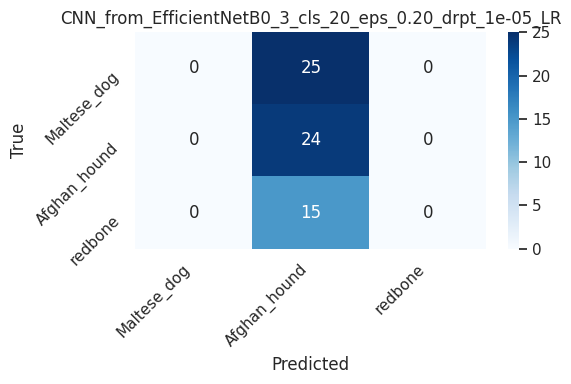

In [8]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.labels, breed_labels_dict.values(), title=f'{experiment_name}')

#### 1.b) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetV2B0`

In [4]:
PRTR_MDL = EfficientNetV2B0
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN_from_{PRTR_MDL.__name__}_{N_CLASSES}_cls_{N_EPOCHS}_eps_{DROPOUT_RATE:.2f}_drpt_{LR}_LR'

Construire le modèle :

In [5]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "CNN_from_EfficientNetV2B0_3_cls_20_eps_0.20_drpt_1e-05_LR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 5,928,275 (22.61 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 5,921,872 (22.59 MB)

None

Entraînement et validation :

In [6]:
torch.cuda.empty_cache()

2026-05-08 00:10:51,215 [INFO] Entraînement du modèle 'CNN_from_EfficientNetV2B0_3_cls_20_eps_0.20_drpt_1e-05_LR'...
W0000 00:00:1778191853.148096 3197022 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-08 00:12:05,152 [INFO] Entraînement du modèle 'CNN_from_EfficientNetV2B0_3_cls_20_eps_0.20_drpt_1e-05_LR' terminé
2026-05-08 00:12:05,153 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN_from_EfficientNetV2B0_3_cls_20_eps_0.20_drpt_1e-05_LR_model.keras'
2026-05-08 00:12:05,636 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN_from_EfficientNetV2B0_3_cls_20_eps_0.20_drpt_1e-05_LR_history.joblib'


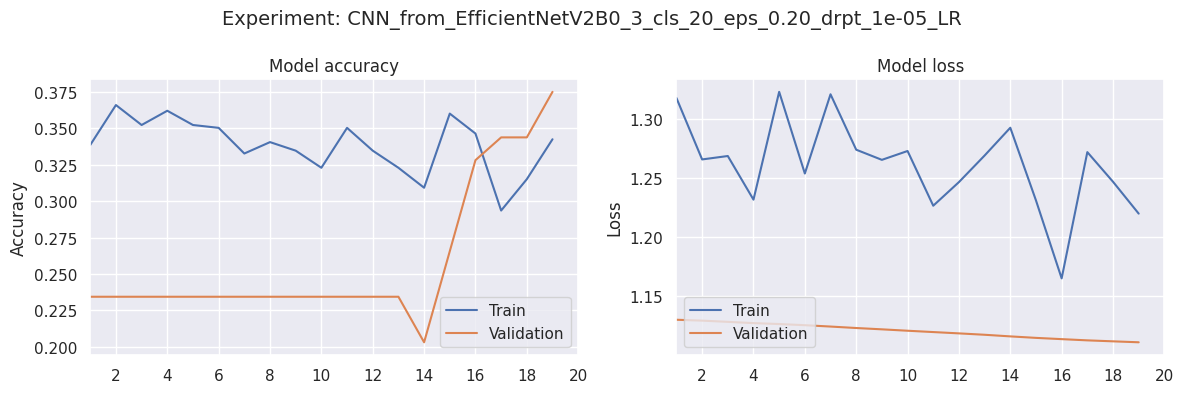

2026-05-08 00:12:06,404 [INFO] Précision finale de l'entraînement: 0.3425
2026-05-08 00:12:06,404 [INFO] Précision finale de la validation: 0.3750
2026-05-08 00:12:06,405 [INFO] Loss finale de l'entraînement: 1.2198
2026-05-08 00:12:06,406 [INFO] Loss finale de la validation: 1.1107


In [7]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'lower right', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-08 00:12:06,413 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.3750 - loss: 1.1101


2026-05-08 00:12:06,771 [INFO] loss, accuracy = [1.1100839376449585, 0.375]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


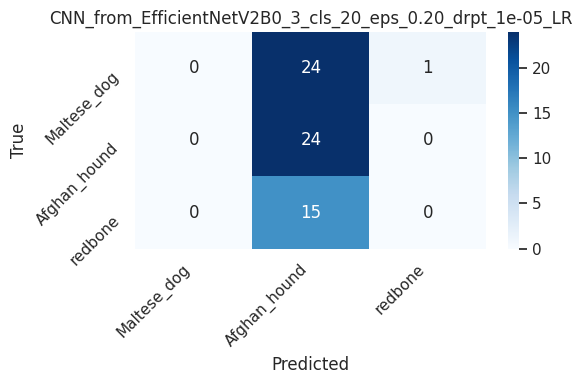

In [8]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.labels, breed_labels_dict.values(), title=f'{experiment_name}')

#### 1.c) Entraînement à 3 classes sur la base du modèle pré-entraîné `VGG16`

In [4]:
PRTR_MDL = VGG16
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN_from_{PRTR_MDL.__name__}_{N_CLASSES}_cls_{N_EPOCHS}_eps_{DROPOUT_RATE:.2f}_drpt_{LR}_LR'

Construire le modèle :

In [5]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_from_VGG16_3_cls_20_eps_0.20_drpt_1e-05_LR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,718,275 (56.15 MB)

 Trainable params: 2,563 (10.01 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

None

Entraînement et validation :

In [6]:
torch.cuda.empty_cache()

2026-05-08 00:13:12,949 [INFO] Entraînement du modèle 'CNN_from_VGG16_3_cls_20_eps_0.20_drpt_1e-05_LR'...
W0000 00:00:1778191995.173995 3204313 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-08 00:14:22,534 [INFO] Entraînement du modèle 'CNN_from_VGG16_3_cls_20_eps_0.20_drpt_1e-05_LR' terminé
2026-05-08 00:14:22,535 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN_from_VGG16_3_cls_20_eps_0.20_drpt_1e-05_LR_model.keras'
2026-05-08 00:14:22,710 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN_from_VGG16_3_cls_20_eps_0.20_drpt_1e-05_LR_history.joblib'


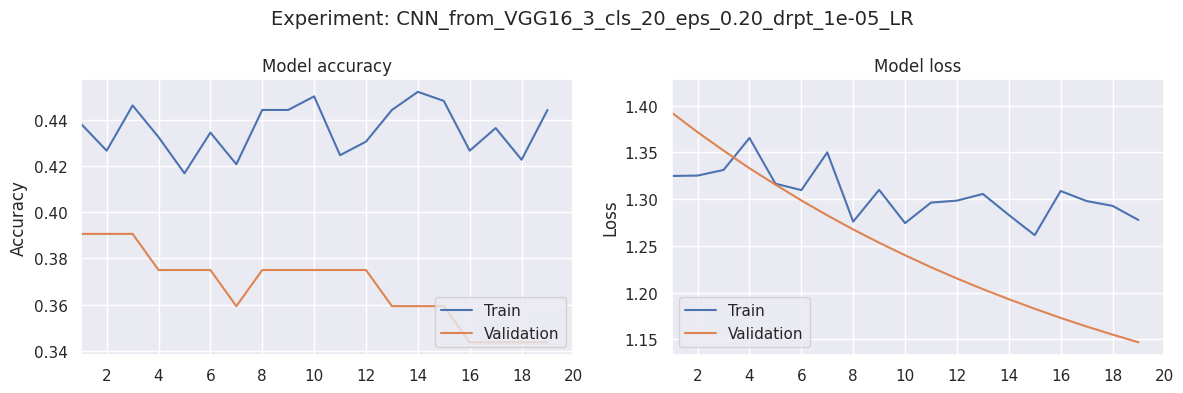

2026-05-08 00:14:23,206 [INFO] Précision finale de l'entraînement: 0.4442
2026-05-08 00:14:23,213 [INFO] Précision finale de la validation: 0.3438
2026-05-08 00:14:23,215 [INFO] Loss finale de l'entraînement: 1.2777
2026-05-08 00:14:23,216 [INFO] Loss finale de la validation: 1.1469


In [7]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'lower right', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-08 00:14:23,229 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.3594 - loss: 1.1393


2026-05-08 00:14:23,653 [INFO] loss, accuracy = [1.1393051147460938, 0.359375]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step


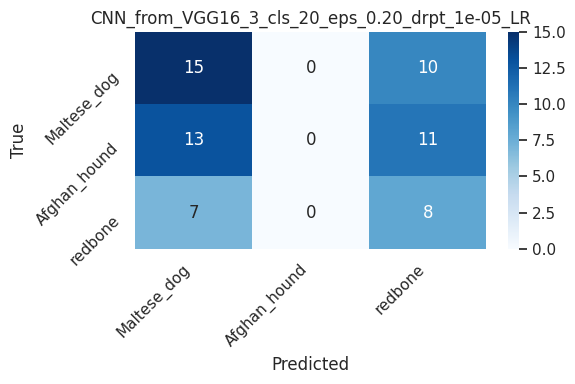

In [8]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.labels, breed_labels_dict.values(), title=f'{experiment_name}')